In [3]:
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import warnings

In [4]:
import duckdb


In [5]:
file_path='D:\\Comp\\supply_chain_data.csv'

In [6]:
data = pd.read_csv(file_path)

In [7]:
data.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [8]:
column_names = data.columns
column_names

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [10]:
missing_value = data.isnull().sum()
missing_value

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [11]:
duplicate_rows= data.duplicated().sum()
duplicate_rows

0

In [12]:
data_p = pd.DataFrame(data)
data_p

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [13]:
data_p.describe

<bound method NDFrame.describe of    Product type    SKU      Price  Availability  Number of products sold  \
0      haircare   SKU0  69.808006            55                      802   
1      skincare   SKU1  14.843523            95                      736   
2      haircare   SKU2  11.319683            34                        8   
3      skincare   SKU3  61.163343            68                       83   
4      skincare   SKU4   4.805496            26                      871   
..          ...    ...        ...           ...                      ...   
95     haircare  SKU95  77.903927            65                      672   
96    cosmetics  SKU96  24.423131            29                      324   
97     haircare  SKU97   3.526111            56                       62   
98     skincare  SKU98  19.754605            43                      913   
99     haircare  SKU99  68.517833            17                      627   

    Revenue generated Customer demographics  Stock le

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [15]:
target = "Revenue generated"
X = data_p.drop(columns=[target])  # Features
y = data_p[target]  # Target variable

In [16]:
# Separate numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [17]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [18]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with a Random Forest Regressor
model = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor(random_state=42))]
)

In [19]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Price', 'Availability', 'Number of products sold', 'Stock levels',
       'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Defect rates', 'Costs'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Product type', 'SKU', 'Customer demographics', 'Shipping carriers',
       'Supplier name', 'Location', 'Inspection results',
       'Transportation modes', 'Routes'],
      dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [20]:
# Make predictions
y_pred = model.predict(X_test)
y_pred

array([6074.85366529, 4307.98363812, 6331.76654288, 4101.1315261 ,
       6615.95383209, 7353.39490912, 5318.56902991, 4809.22732015,
       5757.28433015, 7313.12481368, 5841.02765793, 6328.24744426,
       5685.14692941, 5147.13069715, 5719.97094532, 4985.0542287 ,
       4877.85614492, 5588.81605637, 5221.75612038, 4799.74005395])

In [21]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [22]:
mae, rmse, r2

(2660.2205577251298, 3055.355991214573, -0.16165452599707386)

In [23]:
from sklearn.impute import SimpleImputer

In [24]:
numerical_imputer = SimpleImputer(strategy="median")

In [25]:
# Impute categorical features with the most frequent value
categorical_imputer = SimpleImputer(strategy="most_frequent")

In [26]:
# Calculate Net Profit

data_p['Net Profit'] = data_p['Revenue generated'] - (

    data_p['Manufacturing costs'] + data_p['Shipping costs'] + data_p['Costs'])

data_p.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Net Profit
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,8425.008266
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,6914.501143
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,9397.086845
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,7474.705957
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,1667.108811


In [27]:
# Create a new column for cost variability
data_p["Cost Variability"] = data_p[["Manufacturing costs", "Shipping costs"]].std(axis=1)
# Create the bar chart with adjusted size
fig = px.bar(
    data_p,
    x="SKU",
    y="Cost Variability",
    title="Cost Variability by SKU",
    labels={"Cost Variability": "Cost Variability (Manufacturing & Shipping)"},
    color="Cost Variability"
)
# Adjust figure size
fig.update_layout(
        width=1500,  # Set the width of the figure
    height=400,  # Set the height of the figure
    title={
        "text": "Cost Variability by SKU",  # Title text
        "x": 0.4,  # Center the title (0 is left, 1 is right)
        "xanchor": "center"  # Anchor the title to the center
    }
)

fig.show()

In [28]:
import plotly.express as px
# Revenue generated by Product type
fig_bar = px.bar(
    data_p,
    x='Product type',
    y='Revenue generated',
    title="Revenue by Product Type",
    labels={'Revenue generated': 'Revenue ($)', 'Product type': 'Product Type'},
    hover_data={'Number of products sold': True},
    color_discrete_sequence=["green"]  # Specify the color of the bars
)
fig_bar.show()

In [29]:
#Relation between Transportation modes and Revenue Generated
fig= px.bar(
    data_p,
    x="Transportation modes",
    y="Revenue generated",
    color="SKU",
    title="Revenue Generated by Transportation modes",
    labels={"Revenue Generated": "Revenue"},
    hover_data=["Shipping costs"]
)
fig.show()

In [30]:
fig_geo = px.scatter_geo(
    data_p,
    locations="Location",  # Column with location names
    locationmode="country names",  # Use 'ISO-3', 'country names', or 'USA-states'
    #color="Transportation mode",
    size="Revenue generated",
    hover_name="Location",
    #hover_data_p={"Revenue generated": True, "Transportation mode": True},
    title="Transportation Modes and Revenue by Location",
    projection="natural earth"  # Map projection style
)
fig_geo.show()


In [31]:
pie_chart = px.pie(data_p, values='Revenue generated', names='Customer demographics',

                   title='Revenue by Customer demographics',

                   hover_data=['Number of products sold'],

                   hole=0.7)

pie_chart.update_traces(textposition='outside', textinfo='percent+label')

pie_chart.show()

In [32]:
# Calculate mean defect rates by product type
defect_rates_by_product = data.groupby("Product type")['Defect rates'].mean().reset_index()
fig = px.bar(
    defect_rates_by_product,
    x='Product type',
    y='Defect rates',
    title='Defect Rates by Product Type',
    color_discrete_sequence=px.colors.qualitative.Set3 )
fig.show()

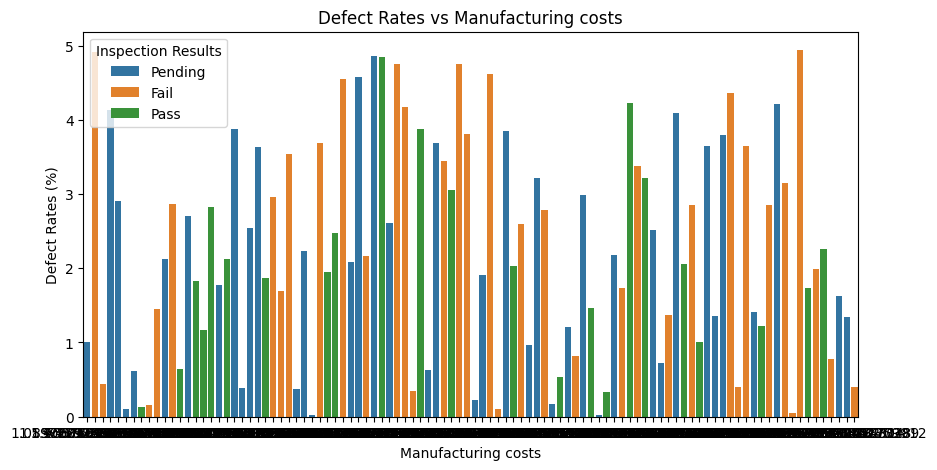

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.barplot(x="Manufacturing costs", y="Defect rates", hue="Inspection results", data=data_p)
plt.title("Defect Rates vs Manufacturing costs")
plt.xlabel("Manufacturing costs")
plt.ylabel("Defect Rates (%)")
plt.legend(title="Inspection Results")
plt.show()

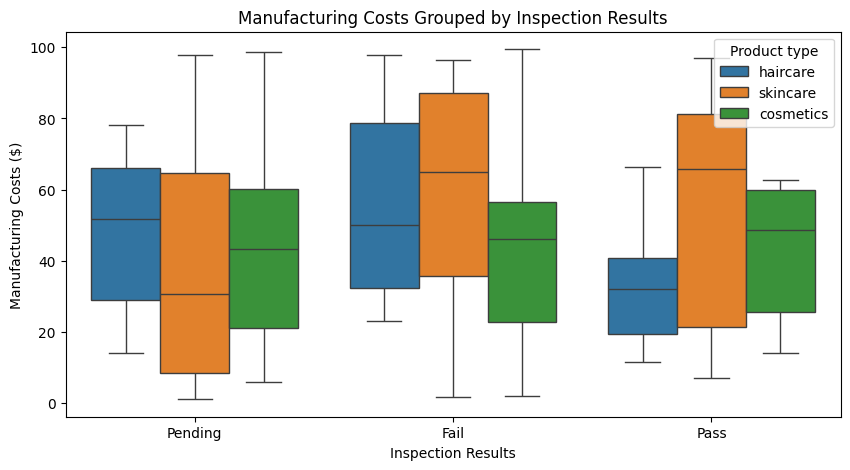

In [34]:
#Manufacturing Costs grouped by Inspection Results
plt.figure(figsize=(10, 5))
sns.boxplot(x="Inspection results", y="Manufacturing costs", data=data_p,hue='Product type',fliersize=0.5,)
plt.title("Manufacturing Costs Grouped by Inspection Results")
plt.ylabel("Manufacturing Costs ($)")
plt.xlabel("Inspection Results")
plt.show()

In [35]:
avg_lead_time = data_p.groupby('Product type')['Lead time'].mean().reset_index()
avg_manufacturing_costs = data_p.groupby('Product type')['Manufacturing costs'].mean().reset_index()
result = pd.merge(avg_lead_time, avg_manufacturing_costs, on='Product type')
result.rename(columns={'Lead time': 'Average Lead Time', 'Manufacturing costs': 'Average Manufacturing Costs'}, inplace=True)
print(result)
fig = px.bar(
    result,
    y='Product type',
    x=['Average Lead Time', 'Average Manufacturing Costs'],
    title="Comparison of Average Lead Time and Manufacturing Costs by Product Type",
    labels={
        "value": "Average Value",
        "Product type": "Product Type",
        "variable": "Metrics"
    },
    barmode='group',pattern_shape='Product type'
)

fig.show()

  Product type  Average Lead Time  Average Manufacturing Costs
0    cosmetics          13.538462                    43.052740
1     haircare          18.705882                    48.457993
2     skincare          18.000000                    48.993157


In [36]:
revenue_chart = px.line(data_p, x='SKU',
                        y='Revenue generated',
                        title='Revenue Generated by SKU',animation_frame='Location',
                        )
revenue_chart.show()

In [37]:
revenue_chart = px.bar(data_p, x='Transportation modes',
                        y='Costs',
                        title='Transport_cost',animation_frame='Routes',color='Location'
                        )
revenue_chart.show()

In [38]:
sku_revenue = data_p.groupby('SKU')['Revenue generated'].sum().reset_index()
sku_revenue =sku_revenue.sort_values(by='Revenue generated', ascending=False)
#show the top 10 SKUs by revenue
top_10_sku_revenue = sku_revenue.head(10)
fig = px.bar(top_10_sku_revenue, x='SKU', y='Revenue generated', title='Top 10 SKUs by Revenue',
             labels={'Revenue generated ($)': 'Total Revenue', 'SKU': 'Stock Keeping Unit (SKU)'},
             text='Revenue generated',)
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(xaxis_tickangle=40)
fig.show()

In [39]:
risk_data = data_p[['SKU', 'Lead times', 'Stock levels','Customer demographics'
]].copy()
risk_data.head()
risk_data['Risk score'] = risk_data['Lead times'] * (1-risk_data.loc[:,'Stock levels'])
print(risk_data)

      SKU  Lead times  Stock levels Customer demographics  Risk score
0    SKU0           7            58            Non-binary        -399
1    SKU1          30            53                Female       -1560
2    SKU2          10             1               Unknown           0
3    SKU3          13            23            Non-binary        -286
4    SKU4           3             5            Non-binary         -12
..    ...         ...           ...                   ...         ...
95  SKU95          14            15               Unknown        -196
96  SKU96           2            67            Non-binary        -132
97  SKU97          19            46                  Male        -855
98  SKU98           1            53                Female         -52
99  SKU99           8            55               Unknown        -432

[100 rows x 5 columns]


In [40]:
import plotly.graph_objects as go
# Sort the risk_data by 'Risk score' in descending order
top_10_risk_data = risk_data.nlargest(10, 'Risk score')
# Create a bar plot using Plotly Graph Objects
fig = go.Figure()
# Add bar trace
fig.add_trace(
    go.Bar(
        x=top_10_risk_data['SKU'],
        y=top_10_risk_data['Risk score'],
        text=top_10_risk_data['Risk score'],
        texttemplate='%{text:.2f}',  # Format the text to 2 decimal places
        textposition='outside',
        marker=dict(color='indianred')  # Customize bar color
    )
)
# Customize layout
fig.update_layout(
    title=dict(
        text='Top 10 Highest-Risk Data',
        x=0.5  # Center the title
    ),
    xaxis=dict(title='SKU'),
    yaxis=dict(title='Risk Score'),
    template='plotly_white'  # Use a clean template
)

# Show the plot
fig.show()

In [41]:
# Holding Cost=Inventory Value×Holding Cost Factor
holding_cost=0.2
def calculate_eoq(data):
    S = data_p['Costs']
    D = data_p['Number of products sold'] 
    H = data_p['Number of products sold'] * holding_cost
    EOQ = np.sqrt((2*S*D)/H)
    return round(EOQ)
data_p['EOQ'] = calculate_eoq(data_p)

In [42]:
comparison_columns = data_p[['SKU', 'EOQ','Order quantities']]
comparison_columns.head()

,SKU,EOQ,Order quantities
0,SKU0,43.0,96
1,SKU1,71.0,37
2,SKU2,38.0,88
3,SKU3,50.0,59
4,SKU4,96.0,56


In [43]:
revenue_avg_by_demo_prod = data_p.groupby(['Customer demographics', 'Product type'])['Revenue generated'].mean().reset_index()
revenue_sum_by_demo_prod = data_p.groupby(['Customer demographics', 'Product type'])['Revenue generated'].sum().reset_index()

In [44]:

revenue_avg_by_demo_prod = data_p.groupby(['Customer demographics', 'Product type'])['Revenue generated'].mean().reset_index()
revenue_sum_by_demo_prod = data_p.groupby(['Customer demographics', 'Product type'])['Revenue generated'].sum().reset_index()
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create a palette of different colors for each product type
colors = px.colors.qualitative.Set3

# Create a subplot with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, subplot_titles=('Average Revenue', 'Total Revenue'))

# Plot for average revenue
for i, product_type in enumerate(revenue_avg_by_demo_prod['Product type'].unique()):
    subset = revenue_avg_by_demo_prod[revenue_avg_by_demo_prod['Product type'] == product_type]
    fig.add_trace(
        go.Bar(
            x=subset['Customer demographics'],
            y=subset['Revenue generated'],
            name=product_type,
            marker_color=colors[i]
        ),
        row=1, col=1
    )
# Plot for total revenue without legend
for i, product_type in enumerate(revenue_sum_by_demo_prod['Product type'].unique()):
    subset = revenue_sum_by_demo_prod[revenue_sum_by_demo_prod['Product type'] == product_type]
    fig.add_trace(
        go.Bar(
            x=subset['Customer demographics'],
            y=subset['Revenue generated'],
            showlegend=False,  # Hide legend for this subplot
            marker_color=colors[i]
        ),
        row=1, col=2
    )
# Beautify the subplot and show the legend for the first subplot
fig.update_layout(
    title='Revenue Analysis by Customer Demographics and Product Type',
    xaxis=dict(title='Customer Demographics'),
    yaxis=dict(title='Revenue'),
    xaxis2=dict(title='Customer Demographics'),
    yaxis2=dict(title='Revenue'),
    title_x=0.5,
    showlegend=True  # Show legend for the first subplot
)
fig.show()

In [45]:
avg_lead_times_transport = data_p.groupby(['Transportation modes'])['Lead times'].mean().reset_index()
fig = px.bar(avg_lead_times_transport, x='Transportation modes', y='Lead times',
             labels={'Transportation modes': 'Transportation Mode', 'Lead times': 'Average Lead Time'},
             title='Average Lead Times by Transportation Mode')
# Customize the color scale for bars
color_scale = px.colors.qualitative.Set3  # You can choose a different color scale
fig.update_traces(marker_color=color_scale)
# Customize the layout for beautification
fig.update_layout(
    title=dict(text='Average Lead Times by Transportation Mode', x=0.5),
    xaxis_title='Transportation Mode',
    yaxis_title='Average Lead Time',
    xaxis_tickangle=-45,  # Rotate x-axis labels for better readability
    font=dict(family="Calibri", size=15),
    showlegend=False  # Remove legend
)
fig.show()

In [46]:
best_transportation_mode = avg_lead_times_transport.loc[avg_lead_times_transport['Lead times'].idxmin()]
best_transportation_mode

Transportation modes          Sea
Lead times              12.176471
Name: 3, dtype: object

In [47]:
best_transportation_data = data_p[data_p['Transportation modes']==best_transportation_mode['Transportation modes']]
best_transportation_data.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Net Profit,Cost Variability,EOQ
6,skincare,SKU6,4.078333,48,65,7823.476560,Male,11,15,58,...,24,1.085069,Pending,1.000911,Sea,Route A,134.369097,7684.141631,1.976855,37.0
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,...,8,11.423027,Pending,2.709863,Sea,Route B,505.557134,6996.978315,5.669790,71.0
15,skincare,SKU15,36.989245,94,469,5442.086785,Non-binary,9,8,69,...,7,97.121282,Pass,2.264406,Sea,Route B,127.861800,5214.681664,66.962476,36.0
18,haircare,SKU18,36.443628,23,620,9364.673505,Unknown,10,10,46,...,17,27.107981,Pending,2.231939,Sea,Route A,593.480259,8739.746041,16.099942,77.0
27,cosmetics,SKU27,92.557361,42,352,2686.457224,Unknown,47,9,62,...,4,10.528245,Fail,2.864668,Sea,Route B,762.459182,1906.063045,2.207230,87.0


In [48]:

avg_lead_times_route = data_p.groupby(['Routes'])['Lead times'].mean().reset_index()

# Assuming you have the avg_lead_times_route DataFrame already defined
fig = px.bar(avg_lead_times_route, x='Routes', y='Lead times',
             labels={'Routes': 'Route', 'Lead times': 'Average Lead Time'},
             title='Average Lead Times by Route')
# Customize the color scale for bars
color_scale = px.colors.qualitative.Set3 
fig.update_traces(marker_color=color_scale)
# Customize the layout for beautification
fig.update_layout(
    title=dict(text='Average Lead Times by Route', x=0.5),
    xaxis_title='Route',
    yaxis_title='Average Lead Time',
    xaxis_tickangle=-45,  # Rotate x-axis labels for better readability
    font=dict(family="Arial", size=14),
    showlegend=False  # Remove legend
)

In [49]:
best_route = avg_lead_times_route.loc[avg_lead_times_route['Lead times'].idxmin()]
best_route

Routes          Route A
Lead times    14.697674
Name: 0, dtype: object

In [50]:
X = data_p.loc[:,['Price', 'Availability', 'Stock levels', 'Lead times', 'Order quantities']]
y = data_p.loc[:,'Number of products sold']

In [51]:
# Define the number of folds for cross-validation
num_folds = 10
# Initialize lists to store evaluation metrics
mse_scores = []
rmse_scores = []
mae_scores = []
r2_scores = []

In [52]:
from sklearn.model_selection import KFold
# Create a KFold object
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

In [53]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    params = {
        'loss_function': 'RMSE',
        'learning_rate': 0.05,
        'depth': 16,
        'l2_leaf_reg': 3,
        'random_seed': 42
    }
    
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train,
        
        eval_set=(X_test, y_test),
        early_stopping_rounds=50,
        verbose=10
    )
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    target_range = np.max(y_test) - np.min(y_test)
    
    percentage_mse = (mse / target_range) * 100
    percentage_rmse = (rmse / target_range) * 100
    percentage_mae = (mae / target_range) * 100
    percentage_r2 = (r2 * 100)
    
    mse_scores.append(percentage_mse)
    rmse_scores.append(percentage_rmse)
    mae_scores.append(percentage_mae)
    r2_scores.append(percentage_r2) 
    # Calculate the average scores over all folds
avg_mse = np.mean(mse_scores)
avg_rmse = np.mean(rmse_scores)
avg_mae = np.mean(mae_scores)
avg_r2 = np.mean(r2_scores)
# Print the results
print(f"Average Mean Squared Error: {avg_mse:.2f}%")
print(f"Average Root Mean Squared Error: {avg_rmse:.2f}%")
print(f"Average Mean Absolute Error: {avg_mae:.2f}%")
print(f"Average R-squared: {avg_r2:.2f}%")

0:	learn: 287.6799034	test: 391.4635439	best: 391.4635439 (0)	total: 156ms	remaining: 2m 35s
10:	learn: 257.4634004	test: 395.4151434	best: 390.7877516 (1)	total: 782ms	remaining: 1m 10s
20:	learn: 232.3567722	test: 395.2611816	best: 390.7877516 (1)	total: 1.22s	remaining: 57s
30:	learn: 206.4102585	test: 391.2714148	best: 390.7877516 (1)	total: 2.07s	remaining: 1m 4s
40:	learn: 184.8303178	test: 390.8741268	best: 388.7399574 (32)	total: 2.98s	remaining: 1m 9s
50:	learn: 163.6689262	test: 391.0864931	best: 388.7399574 (32)	total: 4.07s	remaining: 1m 15s
60:	learn: 146.1960057	test: 391.1814644	best: 388.7399574 (32)	total: 4.52s	remaining: 1m 9s
70:	learn: 129.8080713	test: 389.1311777	best: 388.7399574 (32)	total: 5.61s	remaining: 1m 13s
80:	learn: 114.7488843	test: 391.3025455	best: 388.7399574 (32)	total: 6.39s	remaining: 1m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 388.7399574
bestIteration = 32

Shrink model to first 33 iterations.
0:	learn: 307.6757242

In [54]:
params = {
    'objective': 'regression',
    'metric': 'mean_squared_error',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

In [55]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Create LightGBM datasets for training and testing
    train_data = lgb.Dataset(X_train, label=y_train)
    test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
    
    # Add early stopping
    num_round = 100  # Increase the number of boosting rounds
    #callbacks = [lgb.early_stopping(stopping_rounds=5),
                # lgb.log_evaluation(period=10)]

    # Train the model with early stopping
    bst = lgb.train(
        params,
        train_data,
        num_round,
        valid_sets=[test_data]
       #callbacks=callbacks,
        #verbose_eval=10
    )
    
    # Make predictions on the test set
    y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Calculate the target range
    target_range = np.max(y_test) - np.min(y_test)

    # Calculate metrics as percentages
    percentage_mse = (mse / target_range) * 100
    percentage_rmse = (rmse / target_range) * 100
    percentage_mae = (mae / target_range) * 100
    percentage_r2 = (r2 * 100)

    # Append the scores to the respective lists
    mse_scores.append(percentage_mse)
    rmse_scores.append(percentage_rmse)
    mae_scores.append(percentage_mae)
    r2_scores.append(percentage_r2)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 135
[LightGBM] [Info] Number of data points in the train set: 90, number of used features: 5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 449.877778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [56]:
print(mse_scores)
print(rmse_scores)
print(mae_scores)
print(r2_scores)

[15547.196962688242, 5633.568401583002, 9322.332913197857, 10308.928562202547, 8459.534311449383, 14483.454860157113, 9570.245375190068, 12878.244285117986, 9839.805228461788, 8871.5081788785, 16800.361351127733, 8862.124122234258, 9642.61065101147, 13237.590013844527, 10411.99702980403, 17308.30298340364, 12407.14914661805, 13133.848690388731, 11780.081787189021, 7159.243117347212]
[39.99382277750993, 28.308321767746303, 33.61517138219417, 33.20480694889885, 35.401473732557314, 40.16038954814708, 34.652324747957394, 36.6644837975629, 32.0990046141797, 34.12096010501451, 41.57441806893204, 35.505141819511856, 34.18773597405498, 37.62691893071589, 39.2749039271834, 43.90248226642862, 39.45543544335621, 37.026550157059866, 35.121452383218774, 30.651806105018252]
[38.244331618219114, 24.981994075332874, 26.371193488047922, 27.45432617578517, 32.41002245231023, 39.287448961130586, 31.23927417926024, 32.9259466926283, 28.438356662207987, 29.750392454942098, 37.752348580617344, 29.9848405731

In [57]:
avg_mse = np.mean(mse_scores)
avg_rmse = np.mean(rmse_scores)
avg_mae = np.mean(mae_scores)
avg_r2 = np.mean(r2_scores)

# Print the results
print(f"Average Mean Squared Error: {avg_mse:.2f}%")
print(f"Average Root Mean Squared Error: {avg_rmse:.2f}%")
print(f"Average Mean Absolute Error: {avg_mae:.2f}%")
print(f"Average R-squared: {avg_r2:.2f}%")

Average Mean Squared Error: 11282.91%
Average Root Mean Squared Error: 36.13%
Average Mean Absolute Error: 31.96%
Average R-squared: -14.09%


In [58]:
# Extract the features (X) and target (y)
X = data_p.loc[:, 'Production volumes'].values.reshape(-1, 1)
y = data_p.loc[:, 'Manufacturing costs'].values

In [62]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
num_folds = 5
# Initialize lists to store evaluation metrics
mse_scores1 = []
rmse_scores1 = []
mae_scores1 = []
r2_scores1 = []
# Initialize and fit the scaler to the data
scaler = MinMaxScaler()
scaler.fit(X)
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    # Scale the data
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # Define and compile the neural network model
    model = tf.keras.Sequential([
        Dense(128, activation='relu', input_dim=1),
        Dense(64,activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')  
    # Define Early Stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    # Define Model Checkpoint callback to save the best model
    model_checkpoint = ModelCheckpoint('D:\\Comp.weights.h5', save_best_only=True, save_weights_only=True, monitor='val_loss', mode='min')
    # Train the model on the training data with callbacks
    history = model.fit(X_train_scaled,
                        y_train, epochs=100,
                        batch_size=32,
                        validation_data=(X_test_scaled, y_test),
                        verbose=0,
                        callbacks=[early_stopping, model_checkpoint])

    # Load the best model weights from the saved checkpoint
    model.load_weights('D:\\Comp.weights.h5')
    
    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = r2_score(y_test, y_pred)

    # Calculate metrics as percentages
    target_range = np.max(y_test) - np.min(y_test)
    percentage_mse = (mse / target_range) * 100
    percentage_rmse = (rmse / target_range) * 100
    percentage_mae = (mae / target_range) * 100
    percentage_r2 = (r2 * 100)

    # Append the scores to the respective lists
    mse_scores1.append(percentage_mse)
    rmse_scores1.append(percentage_rmse)
    mae_scores1.append(percentage_mae)
    r2_scores1.append(percentage_r2)


c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [64]:
avg_mse1 = np.mean(mse_scores1)
avg_rmse1 = np.mean(rmse_scores1)
avg_mae1 = np.mean(mae_scores1)
avg_r21 = np.mean(r2_scores1)

# Print the results
print(f"Average Mean Squared Error: {avg_mse1:.2f}%")
print(f"Average Root Mean Squared Error: {avg_rmse1:.2f}%")
print(f"Average Mean Absolute Error: {avg_mae1:.2f}%")
print(f"Average R-squared: {avg_r21:.2f}%")

Average Mean Squared Error: 964.68%
Average Root Mean Squared Error: 31.93%
Average Mean Absolute Error: 27.26%
Average R-squared: -14.32%


In [66]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

num_folds = 5
mse_scores2, rmse_scores2, mae_scores2, r2_scores2 = [], [], [], []

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    nn_model = tf.keras.Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    nn_model.compile(optimizer='adam', loss='mean_squared_error')
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint('D:\\Comp.weights.h5', 
                                       save_best_only=True, 
                                       save_weights_only=True, 
                                       monitor='val_loss', 
                                       mode='min')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
    
    history = nn_model.fit(X_train,
                        y_train, 
                        epochs=200,
                        batch_size=32,
                        validation_data=(X_test, y_test),
                        verbose=1,
                        callbacks=[early_stopping, model_checkpoint, reduce_lr])
    
    nn_model.load_weights('D:\\Comp.weights.h5')
    
    y_pred = nn_model.predict(X_test).flatten()
    
    mse2 = mean_squared_error(y_test, y_pred)
    rmse2 = np.sqrt(mse)
    mae2 = np.mean(np.abs(y_test - y_pred))
    r22= r2_score(y_test, y_pred)
    
    target_range2 = np.max(y_test) - np.min(y_test)
    percentage_mse2= (mse / target_range) * 100
    percentage_rmse2= (rmse / target_range) * 100
    percentage_mae2 = (mae / target_range) * 100
    percentage_r2 = (r2 * 100)
    
    mse_scores2.append(percentage_mse)
    rmse_scores2.append(percentage_rmse)
    mae_scores2.append(percentage_mae)
    r2_scores2.append(percentage_r2)
    
    print(f"Fold {fold} Results:")
    print(f"MSE: {percentage_mse:.2f}%")
    print(f"RMSE: {percentage_rmse:.2f}%")
    print(f"MAE: {percentage_mae:.2f}%")
    print(f"R-squared: {percentage_r2:.2f}%")
    print("-----------------------------")

# Calculate and print average scores
avg_mse2 = np.mean(mse_scores2)
avg_rmse2 = np.mean(rmse_scores2)
avg_mae2 = np.mean(mae_scores2)
avg_r22 = np.mean(r2_scores2)

print("Final Average Results:")
print(f"Average Mean Squared Error: {avg_mse2:.2f}%")
print(f"Average Root Mean Squared Error: {avg_rmse2:.2f}%")
print(f"Average Mean Absolute Error: {avg_mae2:.2f}%")
print(f"Average R-squared: {avg_r22:.2f}%")

Epoch 1/200


c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 2920.7874 - val_loss: 3703.4155 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 2926.9255 - val_loss: 3696.6206 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2697.2847 - val_loss: 3689.6274 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 2840.3271 - val_loss: 3681.7122 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 2805.2354 - val_loss: 3671.7336 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 2711.5476 - val_loss: 3659.3718 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 2799.1853 - val_loss: 3644.0415 - learning_rate: 0.0010
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 2881.8215 - val_loss: 3624.8657 - learning_rate: 0.0010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 2896.9609 - val_loss: 3601.0195 - learning

c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 2785.4146 - val_loss: 3456.6890 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2919.4812 - val_loss: 3451.7222 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2942.9282 - val_loss: 3445.8267 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2995.4397 - val_loss: 3438.5044 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 2966.5725 - val_loss: 3429.6812 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2884.4951 - val_loss: 3418.9946 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2964.2236 - val_loss: 3405.7312 - learning_rate: 0.0010
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2986.2244 - val_loss: 3389.3306 - learning_rate: 0.0010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 2979.8411 - val_loss: 3369.1321 - learning

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 3206.1089 - val_loss: 2589.5630 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3251.5156 - val_loss: 2587.4324 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 3256.5481 - val_loss: 2585.0278 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3326.6672 - val_loss: 2582.1902 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 3477.8535 - val_loss: 2578.8149 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 3306.6670 - val_loss: 2574.8486 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 3418.5217 - val_loss: 2570.0981 - learning_rate: 0.0010
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 3156.0247 - val_loss: 2564.3228 - learning_rate: 0.0010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 3238.5178 - val_loss: 2557.2737 - learni

c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 3025.5803 - val_loss: 2993.5879 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 2955.5688 - val_loss: 2989.3774 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 3090.2515 - val_loss: 2985.7053 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 3159.4758 - val_loss: 2981.7712 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 3168.4402 - val_loss: 2976.9216 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3145.2678 - val_loss: 2970.1355 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2911.6414 - val_loss: 2961.2292 - learning_rate: 0.0010
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 2900.6123 - val_loss: 2950.0969 - learning_rate: 0.0010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 2934.8152 - val_loss: 2936.3315 - learnin

c:\Users\Kalpr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 3120.7185 - val_loss: 2564.2493 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 3099.2314 - val_loss: 2556.2744 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 3391.7527 - val_loss: 2546.7173 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3293.1599 - val_loss: 2534.7788 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 3215.7471 - val_loss: 2520.0647 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 3146.3704 - val_loss: 2501.8955 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 3144.3867 - val_loss: 2479.4368 - learning_rate: 0.0010
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 3139.3838 - val_loss: 2451.5864 - learning_rate: 0.0010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 2767.2207 - val_loss: 2416.5728 - learnin

In [67]:
 #Find the most optimal production volume to minimize manufacturing cost
min_production_volume = data_p['Production volumes'].min()
max_production_volume = 1000
step_size = 100

cheapest_cost = float('inf')
best_production_volume = None

for production_volume in range(min_production_volume, max_production_volume + 1, step_size):
    normalized_production_volume = scaler.transform(np.array([[production_volume]]))
    predicted_cost = nn_model.predict(normalized_production_volume)

    if predicted_cost[0][0] < cheapest_cost:
        cheapest_cost = predicted_cost[0][0]
        best_production_volume = production_volume

print('Most optimal production volume to minimize manufacturing cost:', best_production_volume)
print('The cheapest manufacturing cost:', cheapest_cost)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Most optimal production volume to minimize manufacturing cost: 104
The cheapest manufacturing cost: 19.007883


In [71]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import numpy as np

num_folds = 5
mse_scores3, rmse_scores3, mae_scores3, r2_scores3 = [], [], [], []
scaler = MinMaxScaler()

# Scale the input data
X_scaled = scaler.fit_transform(X)
X_reshaped = X_scaled

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X_reshaped), 1):
    X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the model
    input_layer = Input(shape=(X_train.shape[1],))
    
    # LSTM branch
    lstm_reshape = tf.keras.layers.Reshape((-1, 1))(input_layer)
    lstm1 = LSTM(64, return_sequences=True)(lstm_reshape)
    lstm2 = LSTM(128)(lstm1)
    
    # Dense branch
    dense1 = Dense(128, activation='relu')(input_layer)
    dropout1 = Dropout(0.3)(dense1)
    
    # Combine branches
    concatenated = concatenate([lstm2, dropout1])
    
    # Output layers
    dense2 = Dense(64, activation='relu')(concatenated)
    dropout2 = Dropout(0.3)(dense2)
    output = Dense(1)(dropout2)
    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Define callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(
        'D:\\Comp.weights.h5',  # Ensure consistent file path
        save_best_only=True,
        save_weights_only=True,
        monitor='val_loss',
        mode='min'
    )
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=0.00001)
    
    # Train the model
    history = model.fit(
        X_train,
        y_train,
        epochs=300,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1,
        callbacks=[early_stopping, model_checkpoint, reduce_lr]
    )
    
    # Load the best weights
    model.load_weights('D:\\Comp.weights.h5')
    
    # Make predictions
    y_pred = model.predict(X_test).flatten()
    
    # Calculate metrics
    mse3 = mean_squared_error(y_test, y_pred)
    rmse3 = np.sqrt(mse3)
    mae3 = np.mean(np.abs(y_test - y_pred))
    r23 = r2_score(y_test, y_pred)
    
    # Calculate metrics as percentages
    target_range = np.max(y_test) - np.min(y_test)
    percentage_mse3 = (mse3 / target_range) * 100
    percentage_rmse3 = (rmse3 / target_range) * 100
    percentage_mae3 = (mae3 / target_range) * 100
    percentage_r23 = (r23 * 100)
    
    mse_scores3.append(percentage_mse3)
    rmse_scores3.append(percentage_rmse3)
    mae_scores3.append(percentage_mae3)
    r2_scores3.append(percentage_r23)
    
    print(f"Fold {fold} Results:")
    print(f"MSE: {percentage_mse3:.2f}%")
    print(f"RMSE: {percentage_rmse3:.2f}%")
    print(f"MAE: {percentage_mae3:.2f}%")
    print(f"R-squared: {percentage_r23:.2f}%")
    print("-----------------------------")

# Calculate and print average scores
avg_mse3 = np.mean(mse_scores3)
avg_rmse3 = np.mean(rmse_scores3)
avg_mae3 = np.mean(mae_scores3)
avg_r23 = np.mean(r2_scores3)
print("Final Average Results:")
print(f"Average Mean Squared Error: {avg_mse3:.2f}%")
print(f"Average Root Mean Squared Error: {avg_rmse3:.2f}%")
print(f"Average Mean Absolute Error: {avg_mae3:.2f}%")
print(f"Average R-squared: {avg_r23:.2f}%")


Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - loss: 3009.9465 - val_loss: 3698.3914 - learning_rate: 0.0010
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 3125.4766 - val_loss: 3689.8735 - learning_rate: 0.0010
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 3036.6870 - val_loss: 3681.2891 - learning_rate: 0.0010
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 3062.7683 - val_loss: 3671.5991 - learning_rate: 0.0010
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 2699.8433 - val_loss: 3660.2720 - learning_rate: 0.0010
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2852.0942 - val_loss: 3645.8782 - learning_rate: 0.0010
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 2912.5798 - val_loss: 3627.2488 - learning_rate: 0.0010
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 2642.4683 - val_loss: 3604.4551 - learning_rate: 0.0010
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2947.2239 - val_loss: 3577.02

In [72]:
# Find the most optimal production volume to minimize manufacturing cost
min_production_volume = data_p['Production volumes'].min()
max_production_volume = 1000
step_size = 100

cheapest_cost = float('inf')
best_production_volume = None

for production_volume in range(min_production_volume, max_production_volume + 1, step_size):
    normalized_production_volume = scaler.transform(np.array([[production_volume]]))
    predicted_cost = model.predict(normalized_production_volume)

    if predicted_cost[0][0] < cheapest_cost:
        cheapest_cost = predicted_cost[0][0]
        best_production_volume = production_volume

print('Most optimal production volume to minimize manufacturing cost:', best_production_volume)
print('The cheapest manufacturing cost:', cheapest_cost)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Most optimal production volume to minimize manufacturing cost: 104
The cheapest manufacturing cost: 21.488827
